### Data Preprocessing in Python

Good closer question. So data preprocessing is basically the process of cleaning and transforming raw data into a format that's actually usable for analysis or modeling, things like handling missing values, removing outliers, encoding categories, and scaling features.

It matters so much because real world data is messy, and the classic saying holds true here, garbage in, garbage out, even the best algorithm will produce poor or misleading results if it's fed dirty, inconsistent, or improperly scaled data.

#### Step 1: Import Libraries and Load Dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler,MinMaxScaler

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


#### Step 2: Inspect Data Structure and Check Missing Values

We understand dataset size, data types and identify any incomplete (missing) data that needs handling.

df.info(): Prints concise summary including count of non-null entries and data type of each column.

df.isnull().sum(): Returns the number of missing values per column.


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [4]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

## Step 3: Statistical Summary and Visualizing Outliers
Get numeric summaries like mean, median, min/max and detect unusual points (outliers). Outliers can skew models if not handled.

df.describe(): Computes count, mean, std deviation, min/max and quartiles for numerical columns.

Boxplots: Visualize spread and detect outliers using matplotlib’s boxplot().

In [5]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


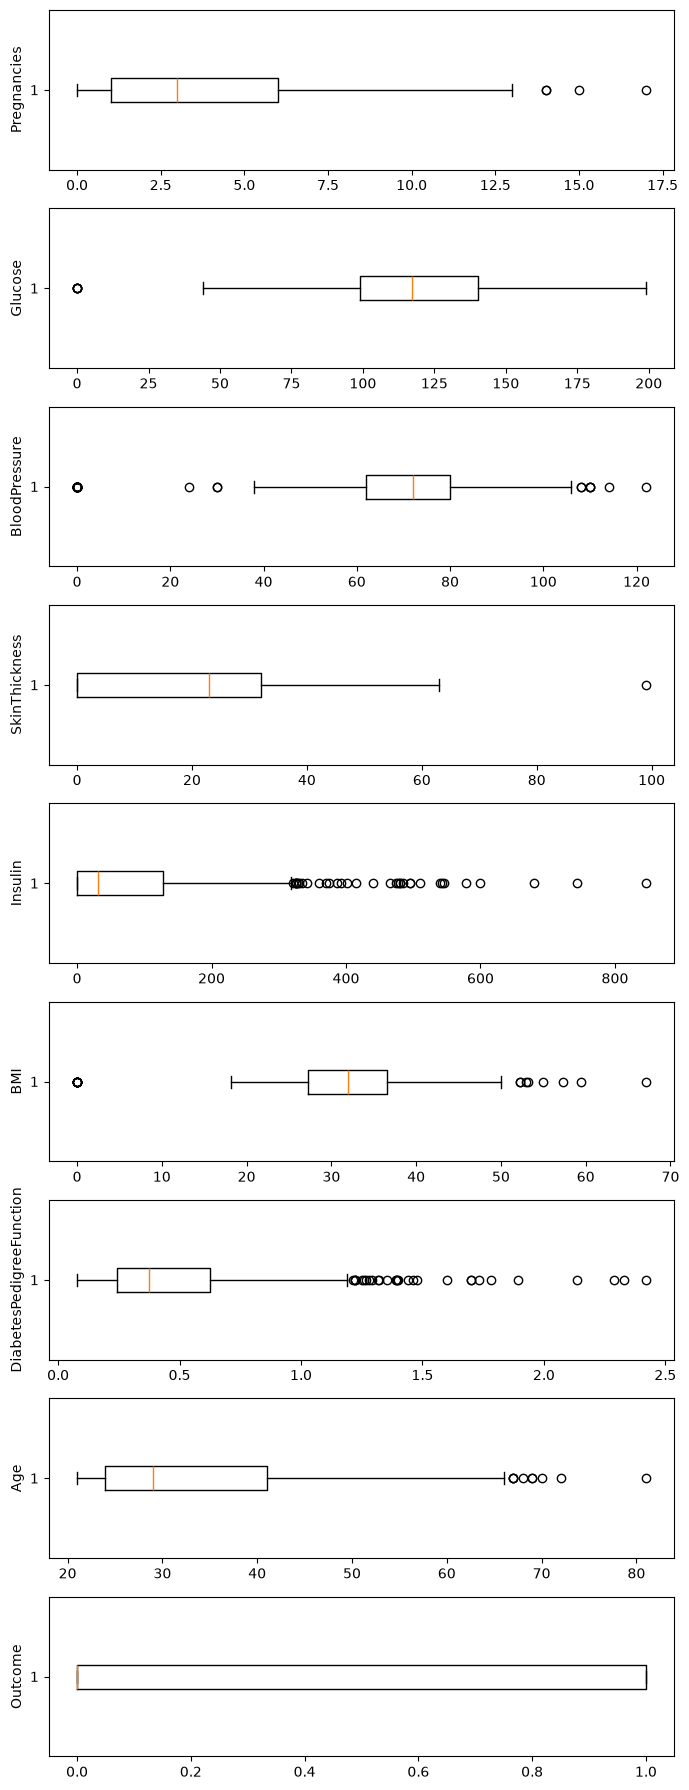

In [14]:
fig,axs = plt.subplots(len(df.columns),1,figsize=(7,18))
for i,col in enumerate(df.columns):
    axs[i].boxplot(df[col],vert= False)
    axs[i].set_ylabel(col)
plt.tight_layout()
plt.show()


### Step 4: Remove Outliers Using the Interquartile Range (IQR) Method
Remove extreme values beyond a reasonable range to improve model robustness.

IQR = Q3 (75th percentile) – Q1 (25th percentile).

Values below Q1 - 1.5IQR or above Q3 + 1.5IQR are outliers.

Calculate lower and upper bounds for each column separately.

Filter data points to keep only those within bounds.

In [15]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [27]:
numeric_columns = df.select_dtypes(include='number').columns
numeric_columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='str')

In [28]:
for col in numeric_columns:
    # q1,q3 = np.percentile(df[col],[25,75])
    q1,q3= df[col].quantile([0.25,0.75])
    iqr = q3-q1

    lower_bound = q1 -iqr*1.5
    upper_bound = q3 + iqr*1.5

    df = df[(df[col]>=lower_bound) & (df[col]<=upper_bound)]

## Step 5: Correlation Analysis
Understand relationships between features and the target variable (Outcome). Correlation helps gauge feature importance.

df.corr(): Computes pairwise correlation coefficients between columns.

Heatmap via seaborn visualizes correlation matrix clearly.

Sorting correlations with corr['Outcome'].sort_values() highlights features most correlated with the target.

In [30]:
corr =df.corr(numeric_only=True)
corr

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.130759,0.206581,-0.088675,-0.090608,0.037389,-0.013274,0.582318,0.235631
Glucose,0.130759,1.000000,0.227750,0.017161,0.280328,0.193989,0.051546,0.268977,0.493355
BloodPressure,0.206581,0.227750,1.000000,0.039799,-0.019897,0.290307,0.022308,0.345872,0.171178
SkinThickness,-0.088675,0.017161,0.039799,1.000000,0.475258,0.383783,0.165758,-0.122427,0.042490
Insulin,-0.090608,0.280328,-0.019897,0.475258,1.000000,0.177380,0.225171,-0.053711,0.114653
BMI,0.037389,0.193989,0.290307,0.383783,0.177380,1.000000,0.148256,0.066110,0.268268
DiabetesPedigreeFunction,-0.013274,0.051546,0.022308,0.165758,0.225171,0.148256,1.000000,0.031168,0.168112
Age,0.582318,0.268977,0.345872,-0.122427,-0.053711,0.066110,0.031168,1.000000,0.267017
Outcome,0.235631,0.493355,0.171178,0.042490,0.114653,0.268268,0.168112,0.267017,1.000000


<Axes: >

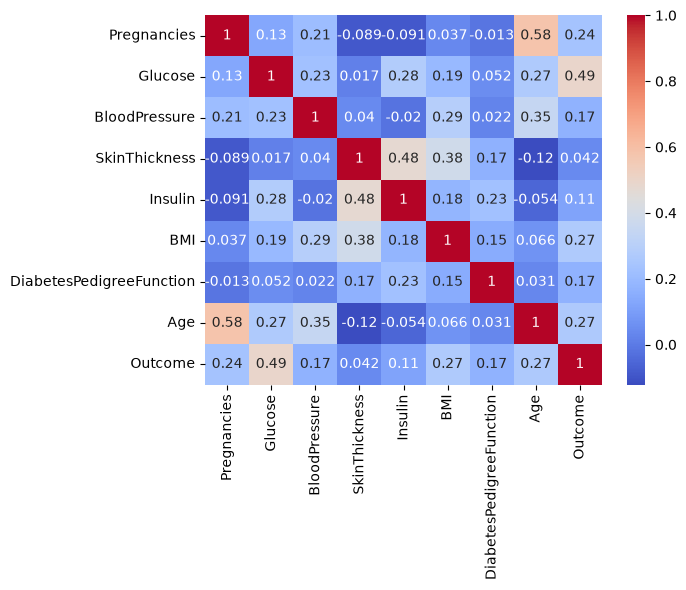

In [32]:
sns.heatmap(data=corr,annot=True,cmap='coolwarm')

In [33]:
corr['Outcome'].sort_values(ascending=False)

Outcome                     1.000000
Glucose                     0.493355
BMI                         0.268268
Age                         0.267017
Pregnancies                 0.235631
BloodPressure               0.171178
DiabetesPedigreeFunction    0.168112
Insulin                     0.114653
SkinThickness               0.042490
Name: Outcome, dtype: float64

## Step 6: Visualize Target Variable Distribution
Check if target classes (Diabetes vs Not Diabetes) are balanced, affecting model training and evaluation.

plt.pie(): Pie chart to display proportion of each class in the target variable 'Outcome'.

Text(0.5, 1.0, 'Outcome Proportionality')

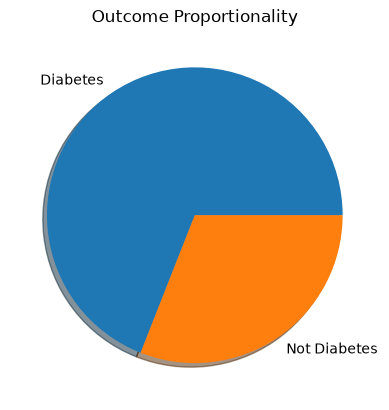

In [40]:
plt.pie(x=df['Outcome'].value_counts(), labels=['Diabetes', 'Not Diabetes'],shadow = True)
plt.title('Outcome Proportionality')

## Step 7: Separate Features and Target Variable
Prepare independent variables (features) and dependent variable (target) separately for modeling.

df.drop(columns=[...]): Drops the target column from features.

Direct column selection df['Outcome'] selects target column.

In [45]:
X = df.drop(columns=['Outcome'])
y = df['Outcome']

## Step 8: Feature Scaling: Normalization and Standardization
Scale features to a common range or distribution, important for many ML algorithms sensitive to feature magnitudes.

1. Normalization (Min-Max Scaling): Rescales features between 0 and 1. Good for algorithms like k-NN and neural networks.

Class: MinMaxScaler from sklearn.

.fit_transform(): Learns min/max from data and applies scaling.

In [43]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

scaler.fit_transform(X)

array([[0.46153846, 0.67532468, 0.5       , ..., 0.49044586, 0.50645756,
        0.65909091],
       [0.07692308, 0.26623377, 0.41176471, ..., 0.26751592, 0.25184502,
        0.22727273],
       [0.61538462, 0.9025974 , 0.38235294, ..., 0.16242038, 0.54797048,
        0.25      ],
       ...,
       [0.38461538, 0.5       , 0.5       , ..., 0.25477707, 0.15405904,
        0.20454545],
       [0.07692308, 0.53246753, 0.32352941, ..., 0.37898089, 0.25      ,
        0.59090909],
       [0.07692308, 0.31818182, 0.47058824, ..., 0.38853503, 0.21863469,
        0.04545455]], shape=(636, 8))

#### Standardization: 
Transforms features to have mean = 0 and standard deviation = 1, useful for normally distributed features.

Class: StandardScaler from sklearn.

In [46]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit_transform(X)

array([[ 6.81425557e-01,  1.00540261e+00, -6.96199653e-04, ...,
         2.56438414e-01,  8.19790711e-01,  1.60468837e+00],
       [-8.57589551e-01, -1.16896300e+00, -5.32035774e-01, ...,
        -8.40893209e-01, -3.07223286e-01, -1.43040721e-01],
       [ 1.29703160e+00,  2.21338350e+00, -7.09148966e-01, ...,
        -1.35820669e+00,  1.00354299e+00, -5.10549792e-02],
       ...,
       [ 3.73622536e-01,  7.35316313e-02, -6.96199653e-04, ...,
        -9.03597873e-01, -7.40061995e-01, -2.35026462e-01],
       [-8.57589551e-01,  2.46100331e-01, -1.06337535e+00, ...,
        -2.92227397e-01, -3.15390054e-01,  1.32873114e+00],
       [-8.57589551e-01, -8.92853085e-01, -1.77809391e-01, ...,
        -2.45198899e-01, -4.54225112e-01, -8.78926652e-01]],
      shape=(636, 8))